### Clean Met TRAM - from Synoptic Data

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import dates
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

# import rioxarray
# import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Open TRAM Station Observations

In [3]:
# filename = '/hdd/snow_hydrology/met_station/tram/JTMA2_MountRoberts_Tram_Synoptic_everything_utc_until_2025-10-08.csv'
filename = '/hdd/snow_hydrology/met_station/tram/JTMA2.2026-03-20.csv' # this one is everything downloaded until 20 March 2026 
df_met = pd.read_csv(filename, sep = ",", low_memory=False, skiprows=10)
df_met['datetime'] = pd.to_datetime(df_met['Date_Time'], utc=True)
# set datetime as the index
df_met = df_met.iloc[1:].copy() # skipping that first row since it's the units row
df_met.set_index('datetime', inplace=True)
df_met.head()

,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,wind_speed_set_1,wind_direction_set_1,wind_gust_set_1,snow_depth_set_1,solar_radiation_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,wind_chill_set_1d,wind_cardinal_direction_set_1d,heat_index_set_1d,dew_point_temperature_set_1d
datetime,,,,,,,,,,,,,,,,
2014-08-27 03:00:00+00:00,JTMA2,2014-08-27T03:00:00Z,8.92,100.0,NaN,NaN,NaN,NaN,NaN,1.524,NaN,NaN,NaN,NaN,NaN,8.92
2014-08-27 03:15:00+00:00,JTMA2,2014-08-27T03:15:00Z,8.9,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.9
2014-08-27 03:30:00+00:00,JTMA2,2014-08-27T03:30:00Z,8.83,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.83
2014-08-27 03:45:00+00:00,JTMA2,2014-08-27T03:45:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.8
2014-08-27 04:00:00+00:00,JTMA2,2014-08-27T04:00:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.762,NaN,NaN,NaN,NaN,NaN,8.8


In [4]:
# Keep only desired variables and rename them
df_met = df_met[
    [
        'air_temp_set_1',
        'relative_humidity_set_1',
        # 'wind_speed_set_1', # wind looks really bad and is only there for a few years before 2020
        # 'wind_direction_set_1',
        'snow_depth_set_1',
        'solar_radiation_set_1',
        'precip_accum_set_1'
    ]
].copy()

df_met = df_met.rename(columns={
    'air_temp_set_1': 'temp',
    'relative_humidity_set_1': 'rh',
    # 'wind_speed_set_1': 'wind', 
    # 'wind_direction_set_1': 'wind_dir',
    'snow_depth_set_1': 'hs',
    'solar_radiation_set_1': 'solar_rad',
    'precip_accum_set_1': 'precip_accum'
})

# -----------------------------------------------------------------------------
# Convert all variables to numeric
# (forces strings/object columns into floats, invalid values -> NaN)
# -----------------------------------------------------------------------------

for col in df_met.columns:
    df_met[col] = pd.to_numeric(df_met[col], errors='coerce')

# -----------------------------------------------------------------------------
# Fix datetime index
# -----------------------------------------------------------------------------

df_met.index = pd.to_datetime(df_met.index, utc=True)
df_met = df_met.sort_index()

# Remove timezone for xarray compatibility
df_met.index = df_met.index.tz_convert(None)

# -----------------------------------------------------------------------------
# Convert to xarray
# -----------------------------------------------------------------------------

ds_met = xr.Dataset.from_dataframe(df_met)

# Rename index dimension to time
ds_met = ds_met.rename({'datetime': 'time'})

# -----------------------------------------------------------------------------
# Select desired period
# -----------------------------------------------------------------------------

ds_met = ds_met.sel(
    time=slice(
        "2014-10-01T05:00:00",
        "2025-09-30T05:00:00"
    )
)

# -----------------------------------------------------------------------------
# Check result
# -----------------------------------------------------------------------------

ds_met

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 92896)
Coordinates:
  * time          (time) datetime64[ns] 743kB 2014-10-01T05:00:00 ... 2025-09...
Data variables:
    temp          (time) float64 743kB 1.62 1.57 1.49 1.41 ... 6.68 4.92 4.61
    rh            (time) float64 743kB 100.0 99.8 99.1 98.1 ... 75.72 98.8 99.4
    hs            (time) float64 743kB nan nan nan ... 2.896e+03 2.896e+03
    solar_rad     (time) float64 743kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    precip_accum  (time) float64 743kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan

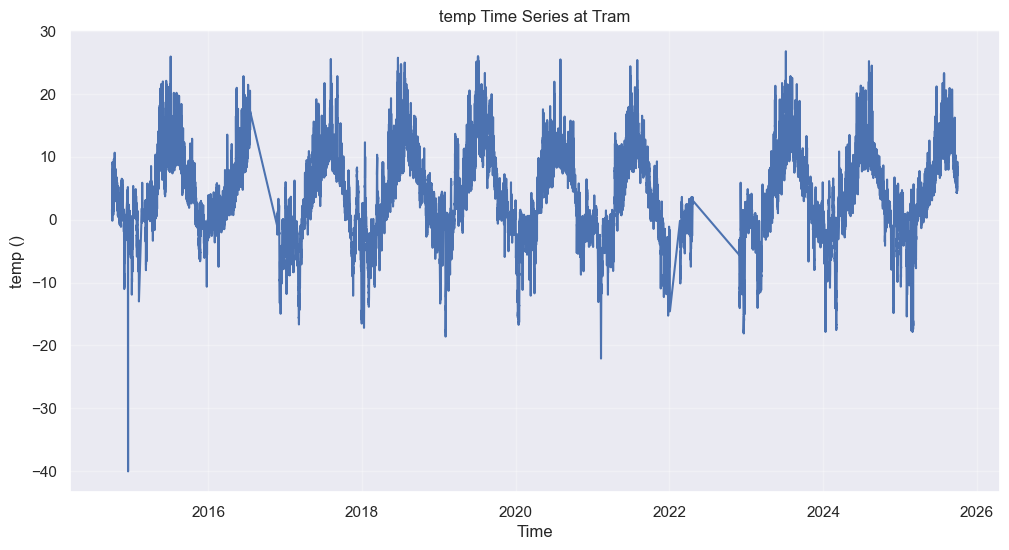

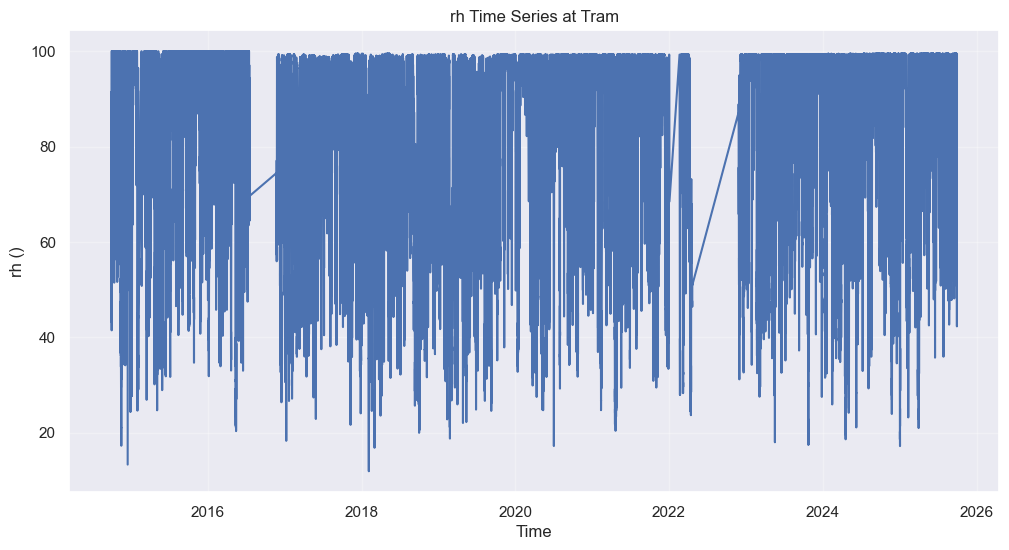

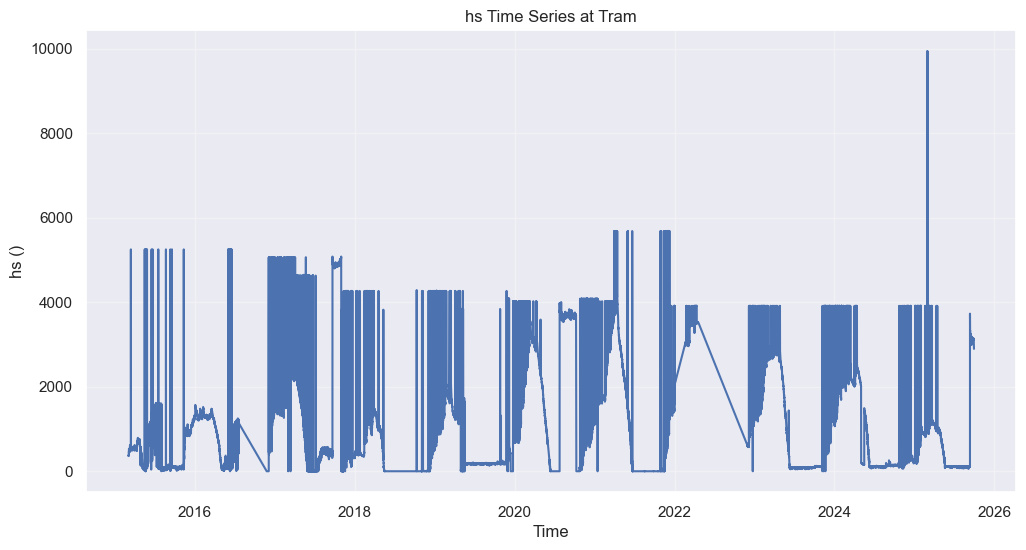

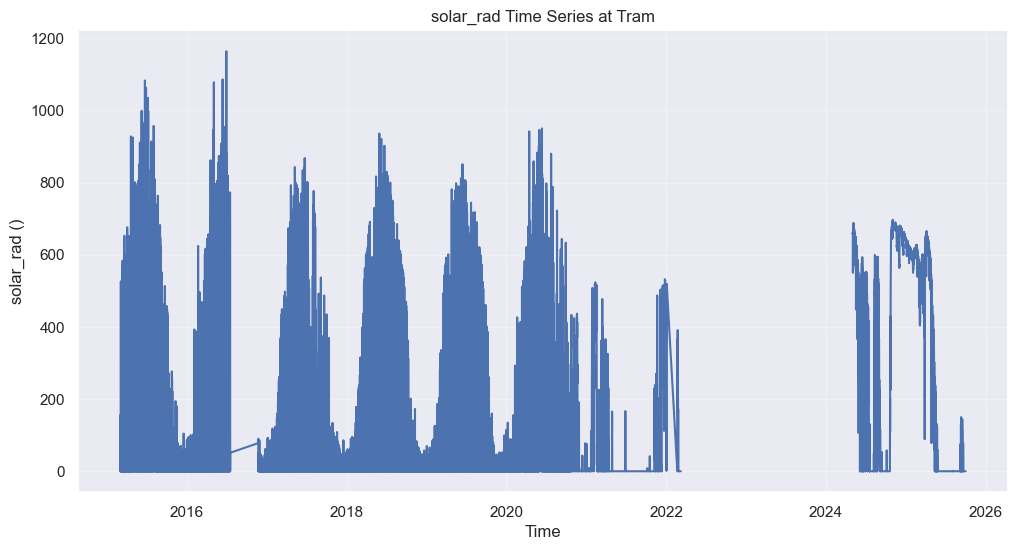

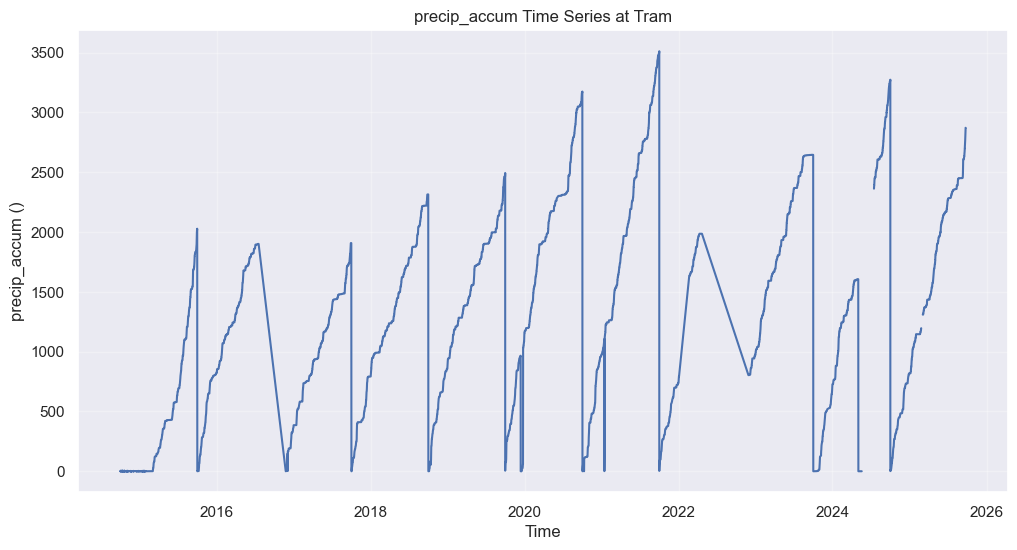

In [5]:
# Comment this out unless we want to look at it again, since we will be cutting and saving a cleaned version of the data
# plot all the variables to see what we have and how they look
for var in ds_met.data_vars:
    plt.figure()
    ds_met[var].plot()
    plt.title(f"{var} Time Series at Tram")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

# Data Cleaning

In [6]:
ds_met

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 92896)
Coordinates:
  * time          (time) datetime64[ns] 743kB 2014-10-01T05:00:00 ... 2025-09...
Data variables:
    temp          (time) float64 743kB 1.62 1.57 1.49 1.41 ... 6.68 4.92 4.61
    rh            (time) float64 743kB 100.0 99.8 99.1 98.1 ... 75.72 98.8 99.4
    hs            (time) float64 743kB nan nan nan ... 2.896e+03 2.896e+03
    solar_rad     (time) float64 743kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    precip_accum  (time) float64 743kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan

In [7]:
# convert units 
ds_met['hs'] = ds_met['hs']*0.1 # convert mm to cm 

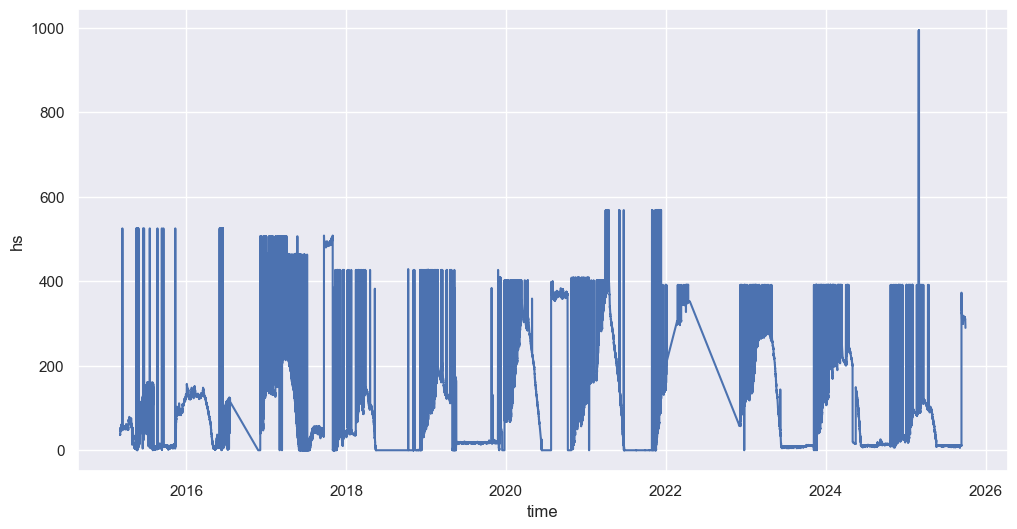

In [8]:
ds_met['hs'].plot()

In [9]:
# cleaning qc code (I've never used before)
def qc_range(da, vmin, vmax):
    return da.where((da >= vmin) & (da <= vmax))

ds_met['precip_accum'] = qc_range(ds_met['precip_accum'], 0, 40000) # in mm already 
ds_met['rh'] = qc_range(ds_met['rh'], 0, 100) # in percent 
ds_met['hs'] = qc_range(ds_met['hs'], 0, 380) # in mm, converted to cm above 
ds_met['temp'] = qc_range(ds_met['temp'], -30, 40) # in C already 


# save attributes 
ds_met["temp"].attrs['units'] = 'C'
ds_met["rh"].attrs['units'] = 'percent'
ds_met['precip_accum'].attrs['units'] = 'mm'
ds_met['hs'].attrs['units'] = 'cm'

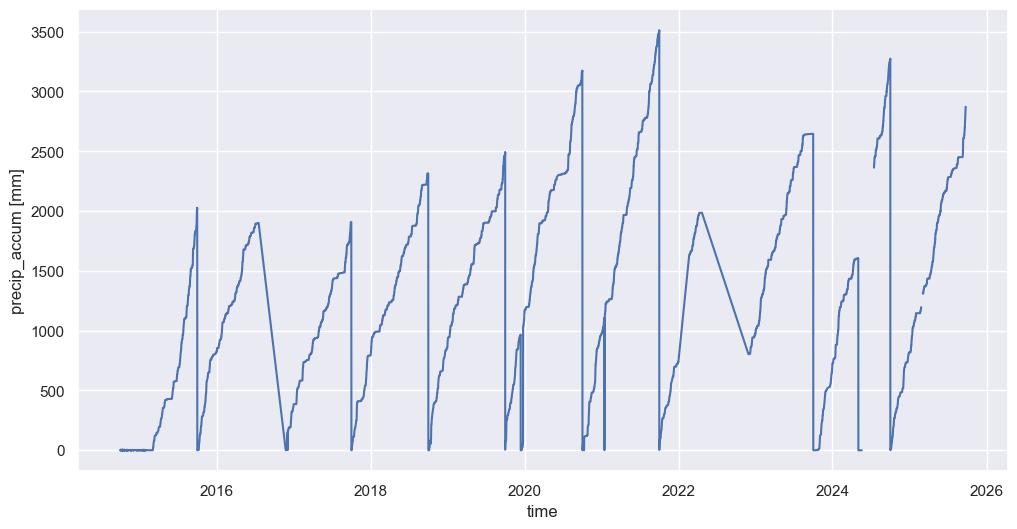

In [10]:
ds_met['precip_accum'].plot()

### Deal with duplicate timestamps (for now, keep the first occurance)

In [11]:
# # Create continuous hourly time axis
# ds_met_hourly = (ds_met.resample(time='1h').asfreq())

Deal with the duplicate timestamps, 

In [12]:
duplicate_mask = ds_met.indexes['time'].duplicated()

print(f"Number of duplicate timestamps: {duplicate_mask.sum()}")

Number of duplicate timestamps: 11


Keep the first one, 

In [13]:
ds_met = ds_met.isel(
    time=~ds_met.indexes['time'].duplicated()
)

In [14]:
print(ds_met.indexes['time'].duplicated().sum())

0


### Now deal with precip a bit, 

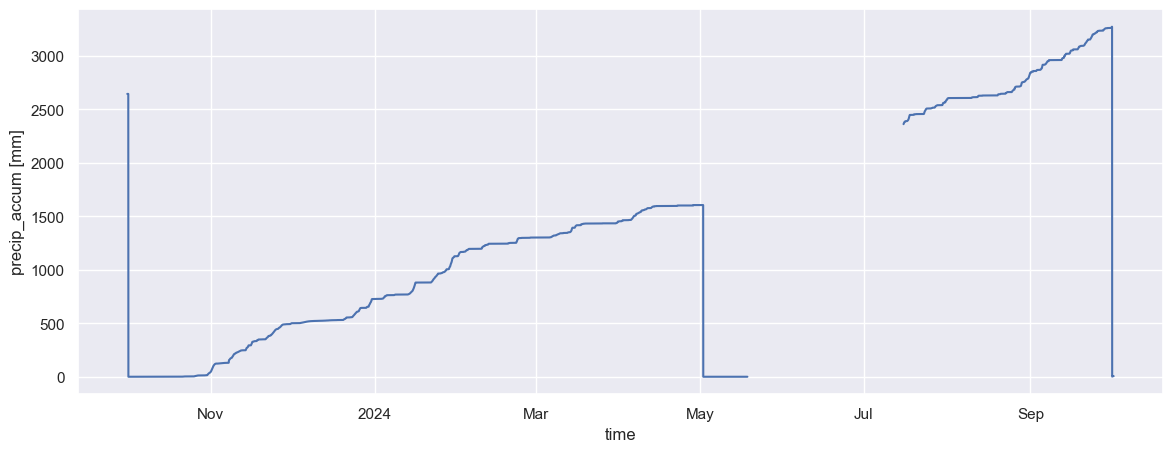

In [15]:
plt.figure(figsize=(14,5))

ds_met["precip_accum"].sel(
    time=slice("2023-10-01","2024-10-01")
).plot()

In [16]:
# ============================================================
# CLEAN MET CUMULATIVE PRECIP AND CREATE HOURLY INCREMENTS
# ============================================================

# Settings
MAX_HOURLY_PSUM_MM = 40.0        # physical/QC upper limit
FLAT_ZERO_IS_MISSING = True      # repeated 0s after reset are outage/missing
FLAT_NONZERO_IS_MISSING = False  # set True only if flat nonzero plateaus are bad

acc = ds_met["precip_accum"]

# Difference cumulative precip on the hourly grid
dacc = acc.diff("time")

# Add first timestep back so output has same length as acc
dacc = xr.concat(
    [xr.full_like(acc.isel(time=0), np.nan), dacc],
    dim="time"
)
dacc = dacc.assign_coords(time=acc.time)

# Basic masks
valid_acc = acc.notnull()
reset_or_drop = dacc < 0
flat = dacc == 0

# Repeated zero values after a reset/drop are usually not valid "no precip";
# they are outage/reset periods where the gauge is not accumulating.
zero_plateau = (acc == 0) & flat

# Optional: flat nonzero plateaus can be treated as missing if the gauge is stuck.
nonzero_plateau = (acc > 0) & flat

# Start with raw hourly increments
precip_1hr = dacc.copy()

# Remove invalid cumulative source values
precip_1hr = precip_1hr.where(valid_acc)

# Drops/resets are not precipitation increments
precip_1hr = precip_1hr.where(~reset_or_drop)

# Repeated zero plateaus after reset/outage should be filled by HRRR later
if FLAT_ZERO_IS_MISSING:
    precip_1hr = precip_1hr.where(~zero_plateau)

# Optional: only use this if you decide long flat nonzero plateaus are sensor outages
if FLAT_NONZERO_IS_MISSING:
    precip_1hr = precip_1hr.where(~nonzero_plateau)

# Remove physically implausible hourly totals
precip_1hr = precip_1hr.where(precip_1hr >= 0)
precip_1hr = precip_1hr.where(precip_1hr <= MAX_HOURLY_PSUM_MM)

# Save hourly MET precipitation [mm h-1]
ds_met["precip_accum_1hr"] = precip_1hr

# Optional rate [mm s-1], if useful for diagnostics
ds_met["precip_rate"] = ds_met["precip_accum_1hr"] / 3600.0

# ============================================================
# RECONSTRUCT CORRECTED MET CUMULATIVE PRECIP BY WATER YEAR
# ============================================================

water_year = xr.where(
    ds_met.time.dt.month >= 10,
    ds_met.time.dt.year + 1,
    ds_met.time.dt.year
)

ds_met["precip_accum_corrected_met"] = (
    ds_met["precip_accum_1hr"]
    .fillna(0)
    .groupby(water_year)
    .cumsum(dim="time")
)

# ============================================================
# DIAGNOSTICS
# ============================================================

print("\nMET precipitation cleaning diagnostics")
print("Valid raw accum fraction:", float(valid_acc.mean()))
print("Negative drops/resets:", int(reset_or_drop.sum()))
print("Zero plateau points masked:", int(zero_plateau.sum()))
print("Nonzero plateau points:", int(nonzero_plateau.sum()))
print("Max hourly MET precip:", float(ds_met["precip_accum_1hr"].max()))
print("Total cleaned MET precip:", float(ds_met["precip_accum_1hr"].sum(skipna=True)))
print("MET precip valid fraction:", float(ds_met["precip_accum_1hr"].notnull().mean()))


MET precipitation cleaning diagnostics
Valid raw accum fraction: 0.9812886903159821
Negative drops/resets: 767
Zero plateau points masked: 8811
Nonzero plateau points: 61905
Max hourly MET precip: 25.653999999999996
Total cleaned MET precip: 26349.197999999997
MET precip valid fraction: 0.8779458470151262


In [17]:
# # ============================================================
# # RECONSTRUCT FINAL MIXED CUMULATIVE PRECIP BY WATER YEAR
# # ============================================================

# water_year_filled = xr.where(
#     ds_filled.time.dt.month >= 10,
#     ds_filled.time.dt.year + 1,
#     ds_filled.time.dt.year
# )

# ds_filled["precip_accum_corrected_filled"] = (
#     ds_filled["PSUM"]
#     .fillna(0)
#     .groupby(water_year_filled)
#     .cumsum(dim="time")
# )

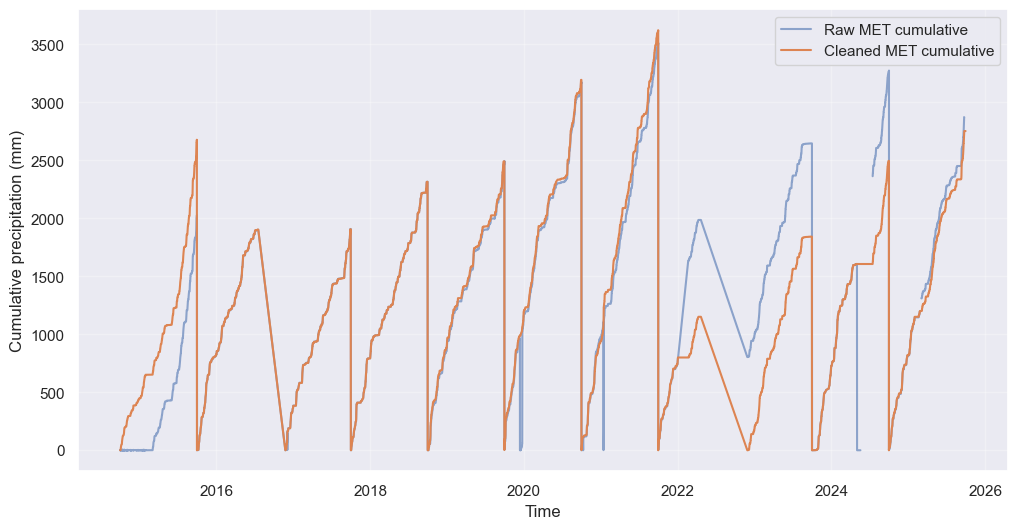

In [18]:
plt.figure(figsize=(12, 6))

ds_met["precip_accum"].plot(
    label="Raw MET cumulative",
    alpha=0.6
)

ds_met["precip_accum_corrected_met"].plot(
    label="Cleaned MET cumulative"
)

# ds_filled["precip_accum_corrected_filled"].plot(
#     label="Final MET + HRRR filled cumulative"
# )

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Previous code, 

In [19]:
# PRECIP
# now we need to deal with precip
# we have total accumulated precip but we need precip per timestep for SNOWPACK 
# so first, calculate precip_rate from precip_accum (hourly timestep)
ds_met["precip_rate"] = ds_met["precip_accum"].diff("time") / 3600.0 # convert from mm/hr to mm/s for SNOWPACK
# and it can never be negative, so set any negative values to 0
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] >= 0, 0)

# and if it is greater than 100 then set to nan
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] < 0.03, np.nan)

# now calculate precip_accum_1hr for comparison with the HRRRAK precip variable (which is in mm/s but we can convert to mm/hr)
ds_met["precip_accum_1hr"] = ds_met["precip_rate"] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# and if it is greater than 100 then set to nan
ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(ds_met["precip_accum_1hr"] < 40, np.nan)

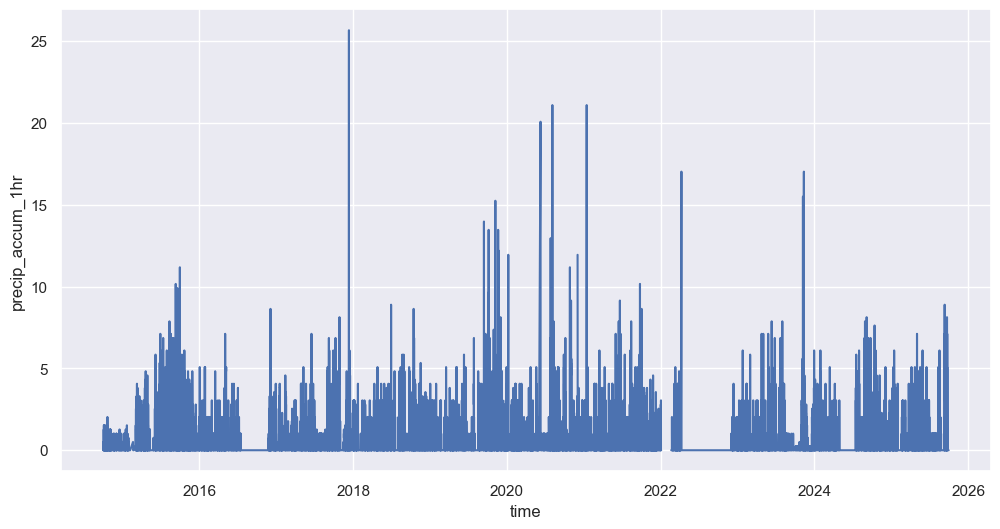

In [20]:
# ds_met['precip_rate'].plot()
ds_met['precip_accum_1hr'].plot()

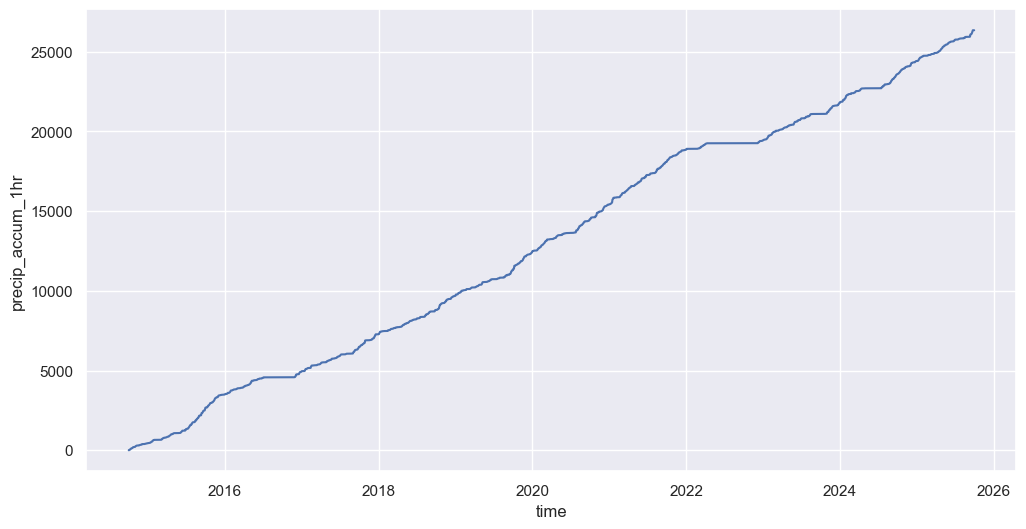

In [21]:
# ds_met['precip_accum'] = ds_met['precip_accum_1hr'].cumsum()
ds_met['precip_accum_1hr'].cumsum().plot()

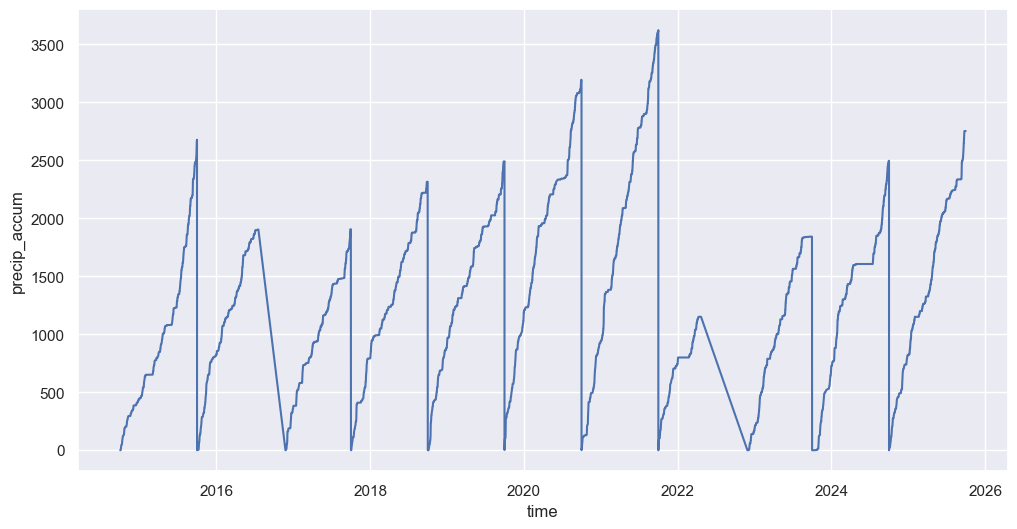

In [22]:
# Define water year
water_year = xr.where(
    ds_met.time.dt.month >= 10,
    ds_met.time.dt.year + 1,
    ds_met.time.dt.year
)

# Accumulated precipitation that resets every Oct 1
ds_met['precip_accum'] = (
    ds_met['precip_accum_1hr']
    .groupby(water_year)
    .cumsum(dim='time')
)

ds_met['precip_accum'].plot()

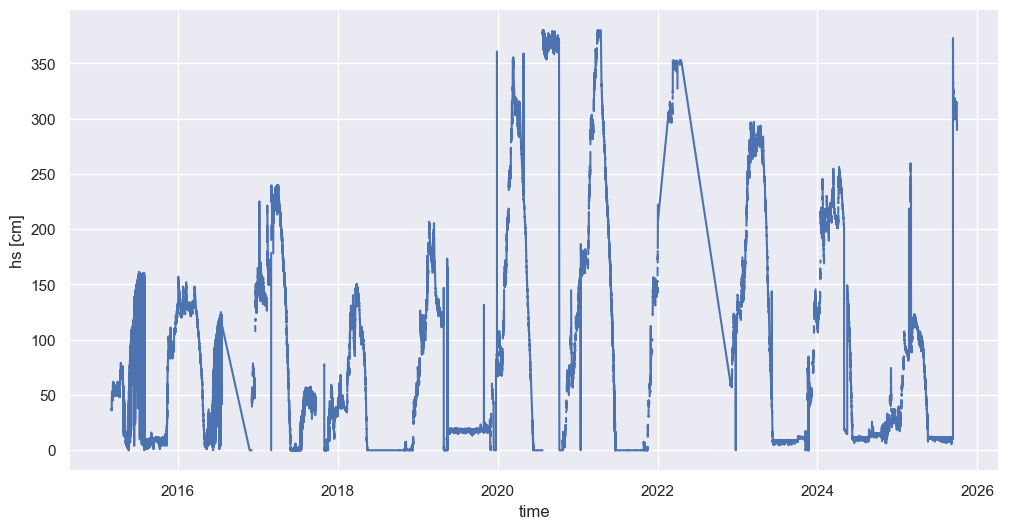

In [23]:
ds_met.hs.plot()

## Cleaning Snow Depth

Manual post-disappearance values set to zero: 2418

Snow depth cleaning diagnostics
Original valid fraction: 0.8166873015018571
Cleaned valid fraction: 0.7400333746030037
Bad hourly-change values removed: 1019
Summer values set to zero: 15481
Large summer values set to NaN: 9511
False winter zeros set to NaN: 411
Isolated local spikes set to NaN: 77
Short isolated snow-event values set to NaN: 129
Max cleaned hs: 379.9078


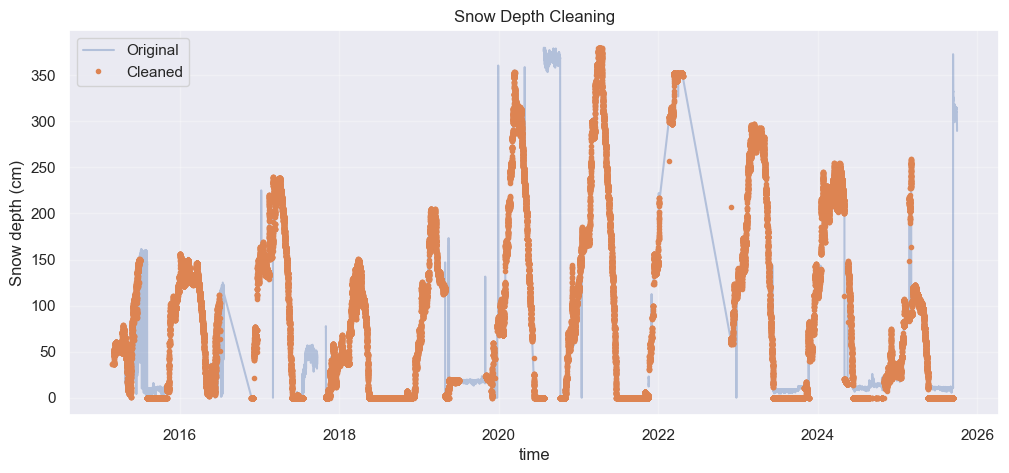

In [24]:
# =============================================================================
# CLEAN SNOW DEPTH OBSERVATIONS
# =============================================================================
#
# Goal:
#   Clean ultrasonic snow depth observations while preserving real snow-season
#   gaps as NaN and forcing known snow-free-season sensor offsets to zero.
#
# Output:
#   ds_met["hs_clean"]  [cm]
#
# Main cleaning steps:
#   1. Remove physically unrealistic hourly jumps.
#   2. Apply short rolling median filter.
#   3. Interpolate only very short gaps.
#   4. Preserve NaNs; only convert negative values to zero.
#   5. Set small summer/off-season residual depths to zero.
#   6. Set large summer/off-season snow-depth artifacts to NaN.
#   7. Remove false zeros during the core snow season.
#   8. Remove isolated spikes relative to local median.
#   9. Remove short isolated snow events.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# -----------------------------------------------------------------------------
# Input
# -----------------------------------------------------------------------------

hs = ds_met["hs"].copy()

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------

# Spike/change filter
max_increase = 15.0        # cm per timestep
max_decrease = -20.0       # cm per timestep

# Rolling median / interpolation
rolling_window = 5         # timesteps
max_interp_gap = "6h"      # only fill short gaps

# Snow-free season handling
snow_free_months = [7, 8, 9, 10]
summer_zero_threshold = 13.0   # cm; <= threshold in summer set to zero

# False-zero handling
snow_season_months = [12, 1, 2, 3, 4]
false_zero_neighbor_threshold = 30.0  # cm
neighbor_window = 3                   # timesteps before/after

# Isolated spike filter
local_median_window = 11      # timesteps
local_median_min_periods = 5
spike_residual_threshold = 25.0  # cm

# Short isolated snow-event filter
snow_threshold = 10.0
snow_event_window = 24 * 7       # 7-day rolling window for hourly data
min_snow_hours_nearby = 24 * 2   # require at least 2 days of snow nearby

# -----------------------------------------------------------------------------
# 1. Remove physically unrealistic timestep changes
# -----------------------------------------------------------------------------

dhs = hs.diff(dim="time")

bad_change = (
    (dhs > max_increase) |
    (dhs < max_decrease)
)

# Pad first timestep so mask has same length as hs
bad_change = xr.concat(
    [
        xr.DataArray(
            [False],
            coords={"time": [hs.time.values[0]]},
            dims="time"
        ),
        bad_change
    ],
    dim="time"
)

bad_change = bad_change.assign_coords(time=hs.time)

hs_clean = hs.where(~bad_change)

# -----------------------------------------------------------------------------
# 2. Rolling median filter
# -----------------------------------------------------------------------------

hs_clean = (
    hs_clean
    .rolling(time=rolling_window, center=True, min_periods=1)
    .median()
)

# -----------------------------------------------------------------------------
# 3. Interpolate only short gaps
# -----------------------------------------------------------------------------

hs_clean = hs_clean.interpolate_na(
    dim="time",
    method="linear",
    max_gap=max_interp_gap
)

# -----------------------------------------------------------------------------
# 4. Remove negative values, while preserving NaNs
# -----------------------------------------------------------------------------

hs_clean = hs_clean.where(
    hs_clean.isnull() | (hs_clean >= 0),
    0
)

# -----------------------------------------------------------------------------
# 5. Force small summer/off-season sensor offsets to zero
# -----------------------------------------------------------------------------

snow_free_season = ds_met.time.dt.month.isin(snow_free_months)

summer_sensor_offset = (
    snow_free_season &
    hs_clean.notnull() &
    (hs_clean <= summer_zero_threshold)
)

hs_clean = hs_clean.where(~summer_sensor_offset, 0)

# -----------------------------------------------------------------------------
# 6. Remove large summer/off-season artifacts
# -----------------------------------------------------------------------------

bad_summer_snow = (
    snow_free_season &
    hs_clean.notnull() &
    (hs_clean > summer_zero_threshold)
)

hs_clean = hs_clean.where(~bad_summer_snow)

# -----------------------------------------------------------------------------
# 7. Remove false zeros during core snow season
# -----------------------------------------------------------------------------

core_snow_season = ds_met.time.dt.month.isin(snow_season_months)

is_zero = (
    hs_clean.notnull() &
    (hs_clean == 0)
)

# Any zero in Jan-Apr is suspicious for these records
zero_in_core_snow_season = (
    core_snow_season &
    is_zero
)

# Any zero surrounded by substantial snow is suspicious
before_snow = (
    hs_clean.shift(time=neighbor_window).notnull() &
    (hs_clean.shift(time=neighbor_window) >= false_zero_neighbor_threshold)
)

after_snow = (
    hs_clean.shift(time=-neighbor_window).notnull() &
    (hs_clean.shift(time=-neighbor_window) >= false_zero_neighbor_threshold)
)

zero_between_snow = (
    is_zero &
    before_snow &
    after_snow
)

false_zero = (
    zero_in_core_snow_season |
    zero_between_snow
)

hs_clean = hs_clean.where(~false_zero)

# -----------------------------------------------------------------------------
# 8. Remove isolated spikes relative to local median
# -----------------------------------------------------------------------------

local_median = (
    hs_clean
    .rolling(
        time=local_median_window,
        center=True,
        min_periods=local_median_min_periods
    )
    .median()
)

residual = np.abs(hs_clean - local_median)

isolated_spike = (
    hs_clean.notnull() &
    local_median.notnull() &
    (residual > spike_residual_threshold)
)

hs_clean = hs_clean.where(~isolated_spike)

# -----------------------------------------------------------------------------
# 9. Remove short isolated snow events
# -----------------------------------------------------------------------------

snow_present = (
    hs_clean.notnull() &
    (hs_clean > snow_threshold)
)

snow_hours_nearby = (
    snow_present
    .rolling(time=snow_event_window, center=True, min_periods=1)
    .sum()
)

isolated_snow = (
    snow_present &
    (snow_hours_nearby < min_snow_hours_nearby)
)

hs_clean = hs_clean.where(~isolated_snow)

# -----------------------------------------------------------------------------
# Manual snow disappearance date corrections
# -----------------------------------------------------------------------------
# After observed melt-out, the sensor reports a persistent ~13 cm offset.
# Force snow depth to zero from the manually identified disappearance date
# through the start of the automated summer-zeroing period.

manual_disappearance_dates = {
    2023: "2023-06-11",
    2024: "2024-06-09",
    2025: "2025-05-21",
}

manual_zero_end = {
    2023: "2023-07-07",
    2024: "2024-07-07",
    2025: "2025-07-07",
}

manual_meltout_zero = xr.zeros_like(hs_clean, dtype=bool)

for wy, start_date in manual_disappearance_dates.items():

    end_date = manual_zero_end[wy]

    this_period = (
        (ds_met.time >= np.datetime64(start_date)) &
        (ds_met.time <  np.datetime64(end_date))
    )

    manual_meltout_zero = manual_meltout_zero | this_period

hs_clean = hs_clean.where(~manual_meltout_zero, 0)

print(
    "Manual post-disappearance values set to zero:",
    int(manual_meltout_zero.sum())
)

# -----------------------------------------------------------------------------
# Save cleaned snow depth
# -----------------------------------------------------------------------------

ds_met["hs_clean"] = hs_clean

# -----------------------------------------------------------------------------
# Diagnostics
# -----------------------------------------------------------------------------

print("\nSnow depth cleaning diagnostics")
print("Original valid fraction:", float(ds_met["hs"].notnull().mean()))
print("Cleaned valid fraction:", float(ds_met["hs_clean"].notnull().mean()))
print("Bad hourly-change values removed:", int(bad_change.sum()))
print("Summer values set to zero:", int(summer_sensor_offset.sum()))
print("Large summer values set to NaN:", int(bad_summer_snow.sum()))
print("False winter zeros set to NaN:", int(false_zero.sum()))
print("Isolated local spikes set to NaN:", int(isolated_spike.sum()))
print("Short isolated snow-event values set to NaN:", int(isolated_snow.sum()))
print("Max cleaned hs:", float(ds_met["hs_clean"].max()))

# -----------------------------------------------------------------------------
# Plot full record
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

ds_met["hs"].plot(
    label="Original",
    alpha=0.35
)

ds_met["hs_clean"].plot(
    label="Cleaned",
    marker="o",
    markersize=3,
    linestyle=""
)

plt.legend()
plt.grid(alpha=0.3)
plt.ylabel("Snow depth (cm)")
plt.title("Snow Depth Cleaning")
plt.show()

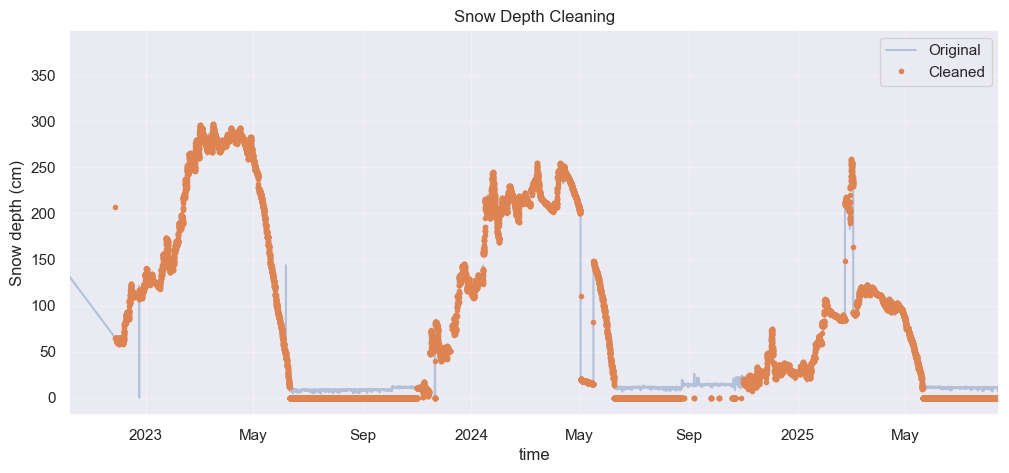

In [25]:
# -----------------------------------------------------------------------------
# Plot full record
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

ds_met["hs"].plot(
    label="Original",
    alpha=0.35
)

ds_met["hs_clean"].plot(
    label="Cleaned",
    marker="o",
    markersize=3,
    linestyle=""
)

# zoom into 2022-2024
ax = plt.gca()
ax.set_xlim(
    pd.Timestamp("2022-10-07"),
    pd.Timestamp("2025-08-15")
)

# plt.ylim(-1,20)
plt.legend()
plt.grid(alpha=0.3)
plt.ylabel("Snow depth (cm)")
plt.title("Snow Depth Cleaning")
plt.show()

In [26]:
# for WY2023, snow disappearance date is 2023-06-11 (sensor then goes to contant 13cm)
# for WY2024, snow disappearance date is 2024-06-09 (sensor then goes to contant 13cm)
# for WY2025, snow disappearance date is 2025-05-21 (sensor then goes to contant 13cm)


### Fixing individual issues for the paper because the algorithmic cleaners are not getting everything 

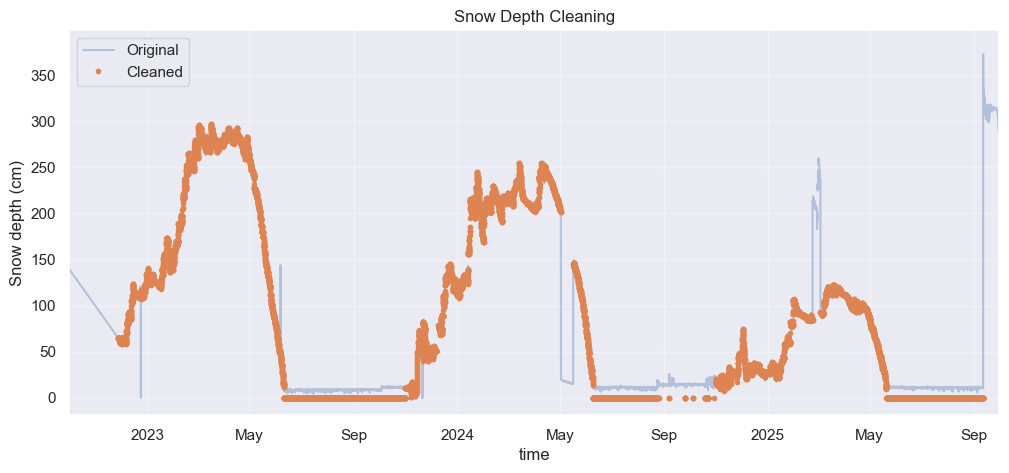

In [27]:
# Remove isolated early-WY2023 artifact

bad_hs = (
    (ds_met.time >= np.datetime64("2022-10-01")) &
    (ds_met.time <= np.datetime64("2022-12-15")) &
    (hs_clean > 150)
)

hs_clean = hs_clean.where(~bad_hs)


# the drop during WY2024 
winter_months = [11, 12, 1, 2, 3, 4]

winter_zero = (
    ds_met.time.dt.month.isin(winter_months) &
    (hs_clean == 0)
)

hs_clean = hs_clean.where(~winter_zero)

hs_clean = hs_clean.interpolate_na(
    dim="time",
    method="linear",
    max_gap="48h"
)

# The other WY2024 issue, to do 
# Remove known bad period during WY2024

bad_wy2024_period = (
    (ds_met.time >= np.datetime64("2024-05-02")) &
    (ds_met.time <= np.datetime64("2024-05-17"))
)

hs_clean = hs_clean.where(~bad_wy2024_period)

# And the WY2025 issue 
# Remove unrealistic high snow depth values only during WY2025
bad_wy2025_high_spike = (
    (ds_met.time >= np.datetime64("2024-10-01")) &
    (ds_met.time <  np.datetime64("2025-10-01")) &
    (hs_clean > 140)
)

hs_clean = hs_clean.where(~bad_wy2025_high_spike)

# -----------------------------------------------------------------------------

ds_met["hs_clean"] = hs_clean

# -----------------------------------------------------------------------------
# Plot full record
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

ds_met["hs"].plot(
    label="Original",
    alpha=0.35
)

ds_met["hs_clean"].plot(
    label="Cleaned",
    marker="o",
    markersize=3,
    linestyle=""
)

# zoom into 2022-2024
ax = plt.gca()
ax.set_xlim(
    pd.Timestamp("2022-10-01"),
    pd.Timestamp("2025-10-01")
)

plt.legend()
plt.grid(alpha=0.3)
plt.ylabel("Snow depth (cm)")
plt.title("Snow Depth Cleaning")
plt.show()

In [28]:
# for hs the hs_final so replace that 
ds_met['hs'] = ds_met['hs_clean']
ds_met = ds_met.drop_vars('hs_clean')
ds_met

<xarray.Dataset> Size: 7MB
Dimensions:                     (time: 92885)
Coordinates:
  * time                        (time) datetime64[ns] 743kB 2014-10-01T05:00:...
Data variables:
    temp                        (time) float64 743kB 1.62 1.57 ... 4.92 4.61
    rh                          (time) float64 743kB 100.0 99.8 ... 98.8 99.4
    hs                          (time) float64 743kB nan nan nan ... nan nan nan
    solar_rad                   (time) float64 743kB nan nan nan ... 0.0 0.0 0.0
    precip_accum                (time) float64 743kB 0.0 0.0 ... 2.753e+03
    precip_accum_1hr            (time) float64 743kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    precip_rate                 (time) float64 743kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    precip_accum_corrected_met  (time) float64 743kB 0.0 0.0 ... 2.753e+03

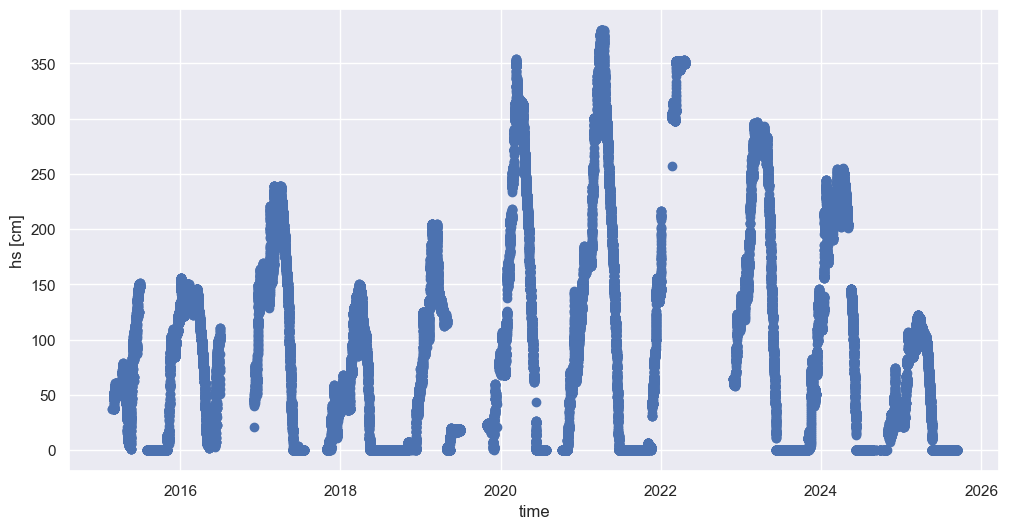

In [29]:
ds_met['hs'].plot(marker='o', linestyle='')

# Save to a new netcdf file, 

In [30]:
# save the first version of the cleaned data 
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met.to_netcdf(file)